In [9]:
import torch
import torchvision
from matplotlib import pyplot as plt
from torch.utils import data
from torchvision import transforms

trans = transforms.ToTensor()

mnist_train = torchvision.datasets.FashionMNIST(root="data",train=True,download=True, transform=trans)
mnist_test = torchvision.datasets.FashionMNIST(root="data", train=False,download=True, transform=trans)

print(f"minist_train:{len(mnist_train)}, mnist_test: {len(mnist_test)}")
print(f"image size: {mnist_train[0][0].shape}, image label={mnist_train[0][1]}")


minist_train:60000, mnist_test: 10000
image size: torch.Size([1, 28, 28]), image label=9


array([<Axes: title={'center': 'coat'}>,
       <Axes: title={'center': 't-shirt'}>,
       <Axes: title={'center': 'shirt'}>,
       <Axes: title={'center': 'dress'}>,
       <Axes: title={'center': 'shirt'}>,
       <Axes: title={'center': 't-shirt'}>,
       <Axes: title={'center': 'bag'}>,
       <Axes: title={'center': 'pullover'}>,
       <Axes: title={'center': 'dress'}>,
       <Axes: title={'center': 'ankle boot'}>,
       <Axes: title={'center': 'dress'}>,
       <Axes: title={'center': 'ankle boot'}>,
       <Axes: title={'center': 'bag'}>, <Axes: title={'center': 'coat'}>,
       <Axes: title={'center': 'ankle boot'}>,
       <Axes: title={'center': 'sneaker'}>,
       <Axes: title={'center': 'sandal'}>,
       <Axes: title={'center': 'trouser'}>], dtype=object)

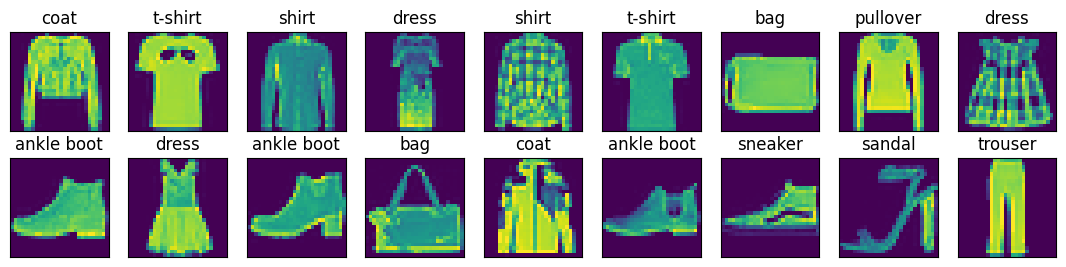

In [11]:
def get_labels(labels):
    text_labels = ['t-shirt', 'trouser', 'pullover', 'dress', 'coat',
                   'sandal', 'shirt', 'sneaker', 'bag', 'ankle boot']
    return [text_labels[int(i)] for i in labels]


def show_images(imgs, num_rows, num_cols, titles=None, scale=1.5):
    fig_size = (num_cols * scale, num_rows * scale)
    _, axes = plt.subplots(num_rows, num_cols, figsize =fig_size)
    axes = axes.flatten()
    
    for i, (ax,img) in enumerate(zip(axes, imgs)):
        if torch.is_tensor(img):
            ax.imshow(img.numpy())
        else:
            ax.imshow(img)
        ax.axes.get_xaxis().set_visible(False)
        ax.axes.get_yaxis().set_visible(False)
        if titles:
            ax.set_title(titles[i])
    return axes

x,y = next(iter(data.DataLoader(mnist_test,batch_size=18,shuffle=True)))
show_images(x.reshape(18,28,28),2,9,titles=get_labels(y))

In [15]:
def build_dataloader(batch_size,num_workers, resize = None):
    trans = [transforms.ToTensor()]
    if resize:
        trans = [transforms.ToTensor(),transforms.Resize(resize)]
    
    trans = transforms.Compose(trans)
    mnist_train = torchvision.datasets.FashionMNIST(root="data",train=True,download=True,transform=trans)
    mnist_test = torchvision.datasets.FashionMNIST(root="data",train=False,download=True,transform=trans)
    
    train_loader = data.DataLoader(mnist_train, batch_size, shuffle=True, num_workers=num_workers)
    test_loader = data.DataLoader(mnist_test, batch_size, shuffle=True, num_workers=num_workers)
    return (train_loader, test_loader)

In [41]:
train_iter, test_iter = build_dataloader(32, num_workers=4)
for X, y in train_iter:
    print(X.shape, X.dtype, y.shape, y.dtype)
    break

torch.Size([32, 1, 28, 28]) torch.float32 torch.Size([32]) torch.int64


In [20]:
# 定义softmax
def softmax(x):
    x_exp = torch.exp(x)
    x_sum = x_exp.sum(axis=1,keepdim=True)
    return x_exp/x_sum

In [23]:
x = torch.tensor([[1,2,3]])
x_softmax = softmax(x)
print(x_softmax)
print(x_softmax.sum())

tensor([[0.0900, 0.2447, 0.6652]])
tensor(1.)


In [52]:
# 定义模型
import torch.nn as nn
class softmaxNet(nn.Module):
    def __init__(self, input_dim, num_class):
        super(softmaxNet,self).__init__()
        self.fc = nn.Linear(input_dim, num_class)
        self.softmax = softmax
    
    def forward(self,x):
        x = x.reshape(x.shape[0],-1)
        return self.softmax(self.fc(x))


In [27]:
# 定义交叉商损失函数
def cross_entry_loss(preds, labels):
    return -torch.log(preds[range(len(labels)),labels])

y = torch.tensor([0, 2])
y_hat = torch.tensor([[0.1, 0.3, 0.6], [0.3, 0.2, 0.5]])
print(y_hat[[0, 1], y])
print(f"cross entry loss: {cross_entry_loss(y_hat,y)}")


tensor([0.1000, 0.5000])
cross entry loss: tensor([2.3026, 0.6931])


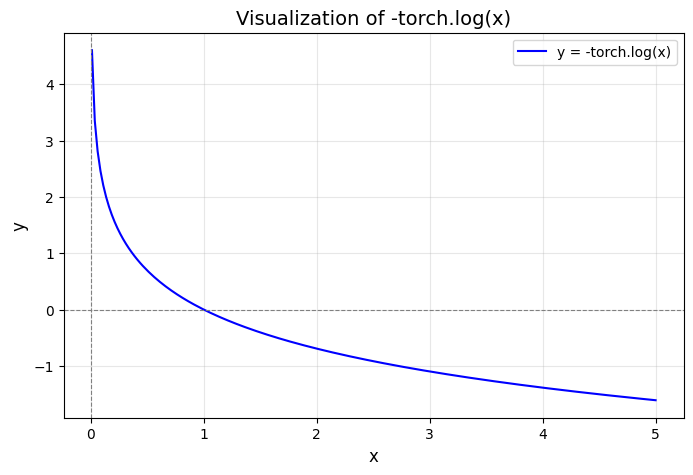

In [31]:
# 可视化-log函数
import torch
import matplotlib.pyplot as plt
import numpy as np

# 创建输入数据
x = torch.linspace(0.01, 5, 200)  # 避免 log(0)，从 0.01 开始
y = -torch.log(x)

# 可视化
plt.figure(figsize=(8, 5))
plt.plot(x.numpy(), y.numpy(), label="y = -torch.log(x)", color="blue")

# 添加标题和标签
plt.title("Visualization of -torch.log(x)", fontsize=14)
plt.xlabel("x", fontsize=12)
plt.ylabel("y", fontsize=12)
plt.axhline(0, color="gray", linestyle="--", linewidth=0.8)
plt.axvline(0, color="gray", linestyle="--", linewidth=0.8)
plt.grid(alpha=0.3)
plt.legend()
plt.show()

In [39]:
def tp(preds, labels):
    if len(preds.shape) > 1 and preds.shape[1] > 1:
        preds = preds.argmax(axis=1)
    cmp = preds.type(labels.dtype) == labels
    return float(cmp.type(preds.dtype).sum())

y = torch.tensor([0, 2])
y_hat = torch.tensor([[0.1, 0.3, 0.6], [0.3, 0.2, 0.5]])
print(f"pred tp: {tp(y_hat,y)}")
print(f"accuracy: {tp(y_hat,y)/len(y)}")

    

pred tp: 1.0
accuracy: 0.5


In [40]:
class Accumulator:
    """在n个变量上累加"""
    def __init__(self, n):
        self.data = [0.0] * n

    def add(self, *args):
        self.data = [a + float(b) for a, b in zip(self.data, args)]

    def reset(self):
        self.data = [0.0] * len(self.data)

    def __getitem__(self, idx):
        return self.data[idx]

In [58]:
def evaluate_accuracy(net, data_iter):
    """计算在指定数据集上模型的精度"""
    if isinstance(net, torch.nn.Module):
        net.eval()  # 将模型设置为评估模式
    metric = Accumulator(2)  # 正确预测数、预测总数
    with torch.no_grad():
        for X, y in data_iter:
            metric.add(tp(net(X), y), y.numel())
    return metric[0] / metric[1]

In [50]:
import matplotlib.pyplot as plt
from IPython import display

# 模拟 d2l 的部分功能
class d2l:
    @staticmethod
    def use_svg_display():
        """使用 SVG 图像格式显示 matplotlib 图"""
        display.set_matplotlib_formats('svg')

    @staticmethod
    def set_axes(axes, xlabel, ylabel, xlim, ylim, xscale, yscale, legend):
        """设置 matplotlib 图的轴"""
        axes.set_xlabel(xlabel)
        axes.set_ylabel(ylabel)
        axes.set_xscale(xscale)
        axes.set_yscale(yscale)
        axes.set_xlim(xlim)
        axes.set_ylim(ylim)
        if legend:
            axes.legend(legend)
        axes.grid()

# Animator 类实现
class Animator:  # @save
    """在动画中绘制数据"""
    def __init__(self, xlabel=None, ylabel=None, legend=None, xlim=None,
                 ylim=None, xscale='linear', yscale='linear',
                 fmts=('-', 'm--', 'g-.', 'r:'), nrows=1, ncols=1,
                 figsize=(3.5, 2.5)):
        # 增量地绘制多条线
        if legend is None:
            legend = []
        d2l.use_svg_display()
        self.fig, self.axes = plt.subplots(nrows, ncols, figsize=figsize)
        if nrows * ncols == 1:
            self.axes = [self.axes]
        # 使用 lambda 函数捕获参数
        self.config_axes = lambda: d2l.set_axes(
            self.axes[0], xlabel, ylabel, xlim, ylim, xscale, yscale, legend)
        self.X, self.Y, self.fmts = None, None, fmts

    def add(self, x, y):
        # 向图表中添加多个数据点
        if not hasattr(y, "__len__"):
            y = [y]
        n = len(y)
        if not hasattr(x, "__len__"):
            x = [x] * n
        if self.X is None:
            self.X = [[] for _ in range(n)]
        if self.Y is None:
            self.Y = [[] for _ in range(n)]
        for i, (a, b) in enumerate(zip(x, y)):
            if a is not None and b is not None:
                self.X[i].append(a)
                self.Y[i].append(b)
        self.axes[0].cla()  # 清除当前绘图区域
        for x, y, fmt in zip(self.X, self.Y, self.fmts):
            self.axes[0].plot(x, y, fmt)
        self.config_axes()  # 配置坐标轴
        display.display(self.fig)
        display.clear_output(wait=True)


In [59]:
# 训练
def train_one_epoch(net, train_iter, loss_func, optimizer):
    if isinstance(net, torch.nn.Module):
        net.train()
    metric = Accumulator(3)
    for x, y in train_iter:
        y_hat = net(x)
        loss = loss_func(y_hat,y)
        optimizer.zero_grad()
        loss.mean().backward()
        optimizer.step()
        metric.add(float(loss.sum()),tp(y_hat,y),y.numel())
    # 返回训练损失和精度
    return metric[0] / metric[2], metric[1] / metric[2]

def train_ch3(net, train_iter, test_iter, loss, num_epochs, updater):  #@save
    """训练模型（定义见第3章）"""
    animator = Animator(xlabel='epoch', xlim=[1, num_epochs], ylim=[0.3, 0.9],
                        legend=['train loss', 'train acc', 'test acc'])
    for epoch in range(num_epochs):
        train_metrics = train_one_epoch(net, train_iter, loss, updater)
        test_acc = evaluate_accuracy(net, test_iter)
        animator.add(epoch + 1, train_metrics + (test_acc,))
    train_loss, train_acc = train_metrics
    assert train_loss < 0.5, train_loss
    assert train_acc <= 1 and train_acc > 0.7, train_acc
    assert test_acc <= 1 and test_acc > 0.7, test_acc

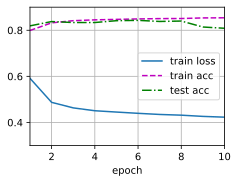

In [60]:
lr = 0.1
num_epochs = 10
train_data = next(iter(train_iter))
input_dim = train_data[0].shape[-1] * train_data[0].shape[-2]
print(input_dim)
net = softmaxNet(input_dim, num_class=10)
sgd = torch.optim.SGD(net.parameters(),lr = lr, momentum=0.001)

train_ch3(net, train_iter, test_iter, cross_entry_loss, num_epochs, sgd)

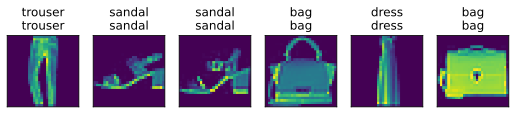

In [61]:
def predict_ch3(net, test_iter, n=6):
    """预测标签（定义见第3章）"""
    for X, y in test_iter:
        break
    trues = get_labels(y)
    preds = get_labels(net(X).argmax(axis=1))
    titles = [true +'\n' + pred for true, pred in zip(trues, preds)]
    show_images(
        X[0:n].reshape((n, 28, 28)), 1, n, titles=titles[0:n])

predict_ch3(net, test_iter)

In [ ]:
x = torch.arange(-8.0, 8.0, 0.1, requires_grad=True)
y = torch.sigmoid(x)
x.grad.data.zero_()
y.backward(torch.ones_like(x),retain_graph=True)